In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
end_date = datetime.strptime('2020-01-01', '%Y-%m-%d')
start_date = end_date - timedelta(days=365*5)

tickers = ['GOOGL', 'TSLA', 'AMZN', 'JPM', 'XOM', 'ASML', 'RACE', 'SIE.DE', 'GLD', 'BTC-USD']

returns_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    returns_df[ticker] = data['Close'].pct_change()

returns_df = returns_df.dropna() 
print(returns_df.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2015-11-01  0.034527  0.112743  0.062151  0.045309 -0.013052 -0.000755   
2015-12-01  0.019873  0.042343  0.016682 -0.009748 -0.037111 -0.042601   
2016-01-01 -0.021414 -0.203367 -0.131515 -0.098895 -0.001283  0.034584   
2016-02-01 -0.057963  0.003818 -0.058739 -0.047434  0.029544 -0.008929   
2016-03-01  0.063690  0.197155  0.074423  0.051865  0.052385  0.102944   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2015-11-01 -0.080904  0.072568 -0.067521  0.201024  
2015-12-01  0.035599 -0.084165 -0.004513  0.141116  
2016-01-01 -0.171458 -0.018914  0.054110 -0.143532  
2016-02-01 -0.045009  0.012546  0.109303  0.186920  
2016-03-01  0.097946  0.089984 -0.008429 -0.047905  


In [3]:
def get_stock_name(ticker_symbol: str):
    ticker = yf.Ticker(ticker_symbol)
    info = ticker.info
    return info.get("longName", "Nome non disponibile")

portfolio = []

for ticker in tickers:
    stock = get_stock_name(ticker)
    portfolio.append(stock)

print(portfolio)

['Alphabet Inc.', 'Tesla, Inc.', 'Amazon.com, Inc.', 'JPMorgan Chase & Co.', 'Exxon Mobil Corporation', 'ASML Holding N.V.', 'Ferrari N.V.', 'Siemens Aktiengesellschaft', 'SPDR Gold Shares', 'Bitcoin USD']


In [4]:
statistics_df = pd.DataFrame({
    'Expected Return': returns_df.mean(),          
    'Variance': returns_df.var(),                  
    'Standard Deviation': returns_df.std()         
})

statistics_df = statistics_df.round(4)
# Rinomina l'indice
statistics_df.index.name = 'Ticker'

print("\nPortfolio Statistics:")
print(statistics_df)


Portfolio Statistics:
         Expected Return  Variance  Standard Deviation
Ticker                                                
GOOGL             0.0134    0.0029              0.0534
TSLA              0.0218    0.0159              0.1262
AMZN              0.0248    0.0059              0.0766
JPM               0.0196    0.0035              0.0589
XOM               0.0014    0.0028              0.0530
ASML              0.0264    0.0042              0.0647
RACE              0.0282    0.0071              0.0844
SIE.DE            0.0097    0.0035              0.0592
GLD               0.0061    0.0015              0.0393
BTC-USD           0.0902    0.0590              0.2429


In [5]:
correlation_matrix = returns_df.corr()

correlation_matrix = correlation_matrix.round(4)

print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
Ticker    GOOGL    TSLA    AMZN     JPM     XOM    ASML    RACE  SIE.DE  \
Ticker                                                                    
GOOGL    1.0000  0.2072  0.5753  0.3007  0.1719  0.6191  0.3540  0.4191   
TSLA     0.2072  1.0000  0.1393  0.1636  0.1017  0.2022  0.1037  0.1355   
AMZN     0.5753  0.1393  1.0000  0.3609  0.3025  0.4351  0.5497  0.2310   
JPM      0.3007  0.1636  0.3609  1.0000  0.3617  0.3918  0.1974  0.4981   
XOM      0.1719  0.1017  0.3025  0.3617  1.0000  0.3932  0.2154  0.4272   
ASML     0.6191  0.2022  0.4351  0.3918  0.3932  1.0000  0.4671  0.4797   
RACE     0.3540  0.1037  0.5497  0.1974  0.2154  0.4671  1.0000  0.1314   
SIE.DE   0.4191  0.1355  0.2310  0.4981  0.4272  0.4797  0.1314  1.0000   
GLD     -0.2261  0.0830 -0.1218 -0.4381 -0.0883  0.0542  0.0543 -0.3552   
BTC-USD -0.0642 -0.0540  0.0381  0.0091 -0.1158 -0.1721  0.1095 -0.1436   

Ticker      GLD  BTC-USD  
Ticker                    
GOOGL   -0.2261  -0.0642

In [6]:
covariance_matrix = returns_df.cov()

covariance_matrix = covariance_matrix.round(4)

print("\nCovariance Matrix")
print(covariance_matrix)


Covariance Matrix
Ticker    GOOGL    TSLA    AMZN     JPM     XOM    ASML    RACE  SIE.DE  \
Ticker                                                                    
GOOGL    0.0029  0.0014  0.0024  0.0009  0.0005  0.0021  0.0016  0.0013   
TSLA     0.0014  0.0159  0.0013  0.0012  0.0007  0.0017  0.0011  0.0010   
AMZN     0.0024  0.0013  0.0059  0.0016  0.0012  0.0022  0.0036  0.0010   
JPM      0.0009  0.0012  0.0016  0.0035  0.0011  0.0015  0.0010  0.0017   
XOM      0.0005  0.0007  0.0012  0.0011  0.0028  0.0013  0.0010  0.0013   
ASML     0.0021  0.0017  0.0022  0.0015  0.0013  0.0042  0.0025  0.0018   
RACE     0.0016  0.0011  0.0036  0.0010  0.0010  0.0025  0.0071  0.0007   
SIE.DE   0.0013  0.0010  0.0010  0.0017  0.0013  0.0018  0.0007  0.0035   
GLD     -0.0005  0.0004 -0.0004 -0.0010 -0.0002  0.0001  0.0002 -0.0008   
BTC-USD -0.0008 -0.0017  0.0007  0.0001 -0.0015 -0.0027  0.0022 -0.0021   

Ticker      GLD  BTC-USD  
Ticker                    
GOOGL   -0.0005  -0.0008  

In [7]:
n=2500
portfolio_returns = []
portfolio_risk = []
portfolio_weights = []

for i in range (n):
    w = np.random.uniform(-1.0,1.0,10)
    w /= np.sum(w)
    w_t = w.T
    p_return = np.dot(w, statistics_df['Expected Return'].values)
    portfolio_returns.append(p_return)
    p_var = np.dot(w,np.dot(covariance_matrix,w_t))
    p_risk = np.sqrt(p_var)
    portfolio_risk.append(p_risk)
    portfolio_weights.append(w)  

portfolios_df = pd.DataFrame({
    'Return': portfolio_returns,
    'Risk': portfolio_risk,
    'Weights': portfolio_weights
})

print(portfolios_df)

        Return      Risk                                            Weights
0     0.016419  0.065430  [0.1923846286950075, 0.17018095678977532, 0.14...
1     0.018814  0.041958  [-0.23243507384353088, 0.16104707976186844, 0....
2     0.011277  0.075787  [0.16632609852543198, 0.39313844827493477, 0.2...
3     0.035943  0.077086  [0.17071789665382678, -0.1587291236230586, 0.3...
4    -0.003015  0.084221  [0.41302911545413024, 0.48685189885929503, 0.1...
...        ...       ...                                                ...
2495  0.072139  0.197005  [-1.0117199299513528, -0.5042453368314189, 0.3...
2496  0.020120  0.071041  [0.05814057481033254, -0.05631175103374675, 0....
2497 -0.059031  0.235067  [1.085630628056265, -0.10102372258088857, -0.5...
2498  0.841893  7.296389  [-5.262306981867352, -5.32985093158482, -16.93...
2499 -0.024203  0.544260  [0.871363162229558, -2.6275552890399125, 0.961...

[2500 rows x 3 columns]


In [8]:
ones = np.ones((covariance_matrix.shape[0], 1))  
cov_inv = np.linalg.inv(covariance_matrix.values)
u = statistics_df["Expected Return"]

a11 = ones.T @ cov_inv @ ones
a11 = a11.item()
a12 = ones.T @ cov_inv @ u
a12 = a12.item()
a22 = u.T @ cov_inv @ u

In [9]:
sigma_min = np.sqrt(1/a11)
mu_min = a12/a11

print(sigma_min)
print(mu_min)

0.019274195465007218
0.006269029884899657


In [10]:
data_rf = yf.download('^TYX', start=start_date, end=end_date, interval='1mo')
rf_annual_pct = data_rf["Close"].mean()
rf = float(rf_annual_pct / 100) 
rf = (1 + rf)**(1/12) - 1     

[*********************100%***********************]  1 of 1 completed
C:\Users\Riccardo\AppData\Local\Temp\ipykernel_13580\281277972.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rf = float(rf_annual_pct / 100)


In [11]:
sigma_tan_sqared = (1/a11)*(1+((a11*a22-a12**2)/((a12-rf*a11)**2)))
sigma_tan = np.sqrt(sigma_tan_sqared)
mu_tan = (a22-rf*a12)/(a12-rf*a11)

sr = (mu_tan-rf)/sigma_tan

print(sigma_tan)
print(mu_tan)

0.05995379823495662
0.04073775473464705


In [12]:
# Crea i sigma_star
sigma_star = np.arange(sigma_min, 0.2, 0.00005)

rad = ((a11 * sigma_star**2) - 1) * (a11 * a22 - a12**2)

# Filtra solo i valori con rad >= 0
mask = rad >= 0

sigma_valid = sigma_star[mask]
rad_valid = rad[mask]

mu_ef = (1/a11) * (a12 + np.sqrt(rad_valid))
mu_inf = (1/a11) * (a12 - np.sqrt(rad_valid))

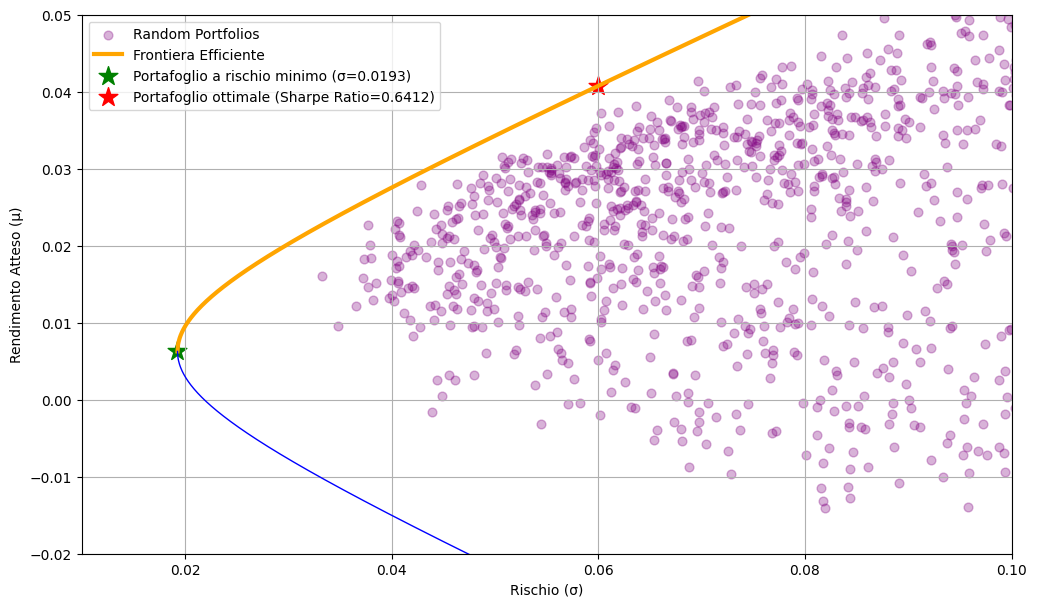

In [13]:
plt.figure(figsize=(12, 7))

plt.scatter(portfolio_risk, 
            portfolio_returns,
            label='Random Portfolios',
            color='purple', 
            marker='o', 
            s=40, 
            alpha=0.3)

plt.plot(sigma_valid, 
         mu_ef, 
         label='Frontiera Efficiente', 
         color='orange', 
         linewidth=3)

plt.plot(sigma_valid, 
         mu_inf, 
         color='blue', 
         linewidth=1)

plt.scatter(sigma_min,
            mu_min,
            label=f'Portafoglio a rischio minimo (σ={sigma_min:.4f})',
            marker='*',
            s=200,
            color='green')

plt.scatter(sigma_tan,
            mu_tan,
            label=f'Portafoglio ottimale (Sharpe Ratio={sr:.4f})',
            marker='*',
            s=200,
            color='red')

plt.xlabel('Rischio (σ)')
plt.ylabel('Rendimento Atteso (µ)')
plt.legend()
plt.xlim(0.01,0.1)
plt.ylim(-0.02,0.05)
plt.grid(True)
plt.show()

In [14]:
w_min_risk = ((1/a11) * cov_inv @ ones).flatten()

p_min_risk = pd.DataFrame({
    "Weight": w_min_risk,
    "Expected Return": returns_df.mean(),
    "Variance": returns_df.var(),
    "Standard Deviation": returns_df.std()
}, index=covariance_matrix.index)

er_min_risk = w_min_risk.T @ u
var_min_risk = w_min_risk.T @ covariance_matrix @ w_min_risk
sd_min_risk = np.sqrt(var_min_risk)

print("\nPortafoglio a minima varianza:")
print("-" * 50)
print(p_min_risk)
print("\nStatistiche")
print(f'Expected Return: {er_min_risk:.4f}')
print(f'Risk: {sd_min_risk:.4f}')


Portafoglio a minima varianza:
--------------------------------------------------
           Weight  Expected Return  Variance  Standard Deviation
Ticker                                                          
GOOGL    0.259286         0.013389  0.002855            0.053431
TSLA    -0.018578         0.021816  0.015931            0.126219
AMZN    -0.032166         0.024751  0.005866            0.076592
JPM      0.216294         0.019564  0.003464            0.058853
XOM      0.093729         0.001368  0.002812            0.053028
ASML    -0.188125         0.026413  0.004186            0.064697
RACE     0.009951         0.028205  0.007117            0.084360
SIE.DE   0.105479         0.009658  0.003509            0.059234
GLD      0.555207         0.006123  0.001546            0.039320
BTC-USD -0.001079         0.090166  0.058996            0.242890

Statistiche
Expected Return: 0.0063
Risk: 0.0193


In [15]:
w_tan = (1/(a12-rf*a11)) * cov_inv @ (np.ravel(u) - rf * np.ravel(ones))

p_tan = pd.DataFrame({
    "Weight": w_tan,
    "Expected Return": returns_df.mean(),
    "Variance": returns_df.var(),
    "Standard Deviation": returns_df.std()
}, index=covariance_matrix.index)

er_tan = w_tan.T @ u
var_tan = w_tan.T @ covariance_matrix @ w_tan
sd_tan = np.sqrt(var_tan)

print("\nPortafoglio Ottimale:")
print("-" * 50)
print(p_tan)
print("\nStatistiche")
print(f'Expected Return: {er_tan:.4f}')
print(f'Risk: {sd_tan:.4f}')


Portafoglio Ottimale:
--------------------------------------------------
           Weight  Expected Return  Variance  Standard Deviation
Ticker                                                          
GOOGL   -0.239372         0.013389  0.002855            0.053431
TSLA     0.054035         0.021816  0.015931            0.126219
AMZN     0.184284         0.024751  0.005866            0.076592
JPM      0.335799         0.019564  0.003464            0.058853
XOM     -0.426235         0.001368  0.002812            0.053028
ASML     0.595127         0.026413  0.004186            0.064697
RACE     0.038444         0.028205  0.007117            0.084360
SIE.DE   0.048613         0.009658  0.003509            0.059234
GLD      0.261286         0.006123  0.001546            0.039320
BTC-USD  0.148019         0.090166  0.058996            0.242890

Statistiche
Expected Return: 0.0407
Risk: 0.0600


In [16]:
weights_df = pd.DataFrame({
    "Titolo": portfolio,
    "Portafoglio rischio minimo": w_min_risk,
    "Portafoglio tangente": w_tan
})

print(weights_df.to_string(index=False))

                    Titolo  Portafoglio rischio minimo  Portafoglio tangente
             Alphabet Inc.                    0.259286             -0.239372
               Tesla, Inc.                   -0.018578              0.054035
          Amazon.com, Inc.                   -0.032166              0.184284
      JPMorgan Chase & Co.                    0.216294              0.335799
   Exxon Mobil Corporation                    0.093729             -0.426235
         ASML Holding N.V.                   -0.188125              0.595127
              Ferrari N.V.                    0.009951              0.038444
Siemens Aktiengesellschaft                    0.105479              0.048613
          SPDR Gold Shares                    0.555207              0.261286
               Bitcoin USD                   -0.001079              0.148019


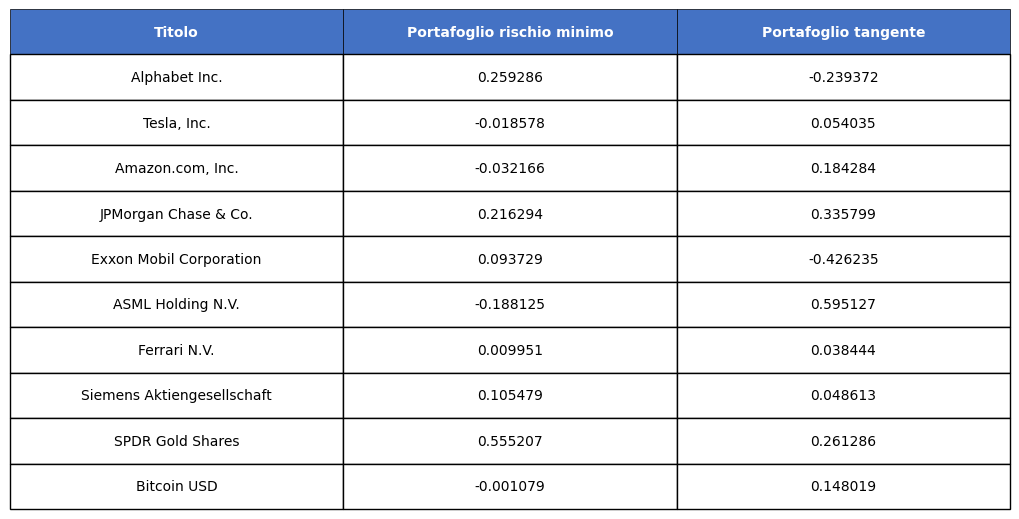

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Crea la tabella specificando esattamente dove posizionarla
table = ax.table(cellText=weights_df.round(6).values,
                colLabels=weights_df.columns,
                cellLoc='center',
                bbox=[0, 0, 1, 1])  

# Stile della tabella
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)  

for j in range(len(weights_df.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_edgecolor('black')
    table[(0, j)].set_linewidth(0.5)

# Rimuovi tutti i margini
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [24]:
# Creo un dataframe per registrare la performance dal 2020
performance_df = pd.DataFrame()

start_date2 = datetime.strptime('2020-01-01', '%Y-%m-%d')
end_date2 = datetime.strptime('2025-01-01', '%Y-%m-%d')

for ticker in tickers:
    data2 = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    performance_df[ticker] = data2['Close'].pct_change()

performance_df = performance_df.dropna() 
print(performance_df.tail())

performance_finale = performance_df.cumsum()
print(performance_finale.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2019-08-01 -0.022714 -0.066222 -0.048474 -0.046226 -0.079075 -0.000898   
2019-09-01  0.025711  0.067639 -0.022733  0.071272  0.043925  0.115943   
2019-10-01  0.030840  0.307427  0.023475  0.061433 -0.043053  0.054545   
2019-11-01  0.035979  0.047695  0.013587  0.063204  0.008287  0.033019   
2019-12-01  0.027069  0.267897  0.026122  0.057984  0.036570  0.098312   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2019-08-01 -0.020673 -0.081220  0.079123 -0.045110  
2019-09-01 -0.023201  0.080264 -0.033948 -0.138806  
2019-10-01  0.039133  0.052214  0.025635  0.109203  
2019-11-01  0.050899  0.132908 -0.032086 -0.177177  
2019-12-01 -0.016224 -0.004952  0.036559 -0.049676  
               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                

In [30]:
start_date = weighted_returns.index.min()
print(start_date)

2015-11-01 00:00:00


In [31]:
sp500_data = yf.download('SPY', start=start_date, end=end_date, interval='1mo')
sp500_returns = sp500_data['Close'].pct_change()
sp500_cumulative_returns = sp500_returns.cumsum() * 100

variance = sp500_cumulative_returns.iloc[-1] - sp500_cumulative_returns.iloc[1]
print(variance)

print(sp500_cumulative_returns.tail())

[*********************100%***********************]  1 of 1 completed

Ticker
SPY    56.571594
dtype: float64
Ticker            SPY
Date                 
2019-08-01  44.080359
2019-09-01  45.557558
2019-10-01  48.240007
2019-11-01  51.859836
2019-12-01  54.261930


In [32]:
weighted_returns = pd.DataFrame()

for date in performance_df.index:
    max_sr_return = sum(performance_df.loc[date] * w_tan)
    weighted_returns.loc[date, 'Optimal'] = max_sr_return
    min_var_return = sum(performance_df.loc[date] * w_min_risk)
    weighted_returns.loc[date, 'Min Risk'] = min_var_return

cumulative_returns = weighted_returns.cumsum() * 100
print("-" * 50)
print(cumulative_returns.tail())

--------------------------------------------------
               Optimal   Min Risk
2019-08-01  179.985089  26.771026
2019-09-01  184.096746  26.110953
2019-10-01  195.286898  28.164255
2019-11-01  196.048837  29.478639
2019-12-01  203.702512  31.312979


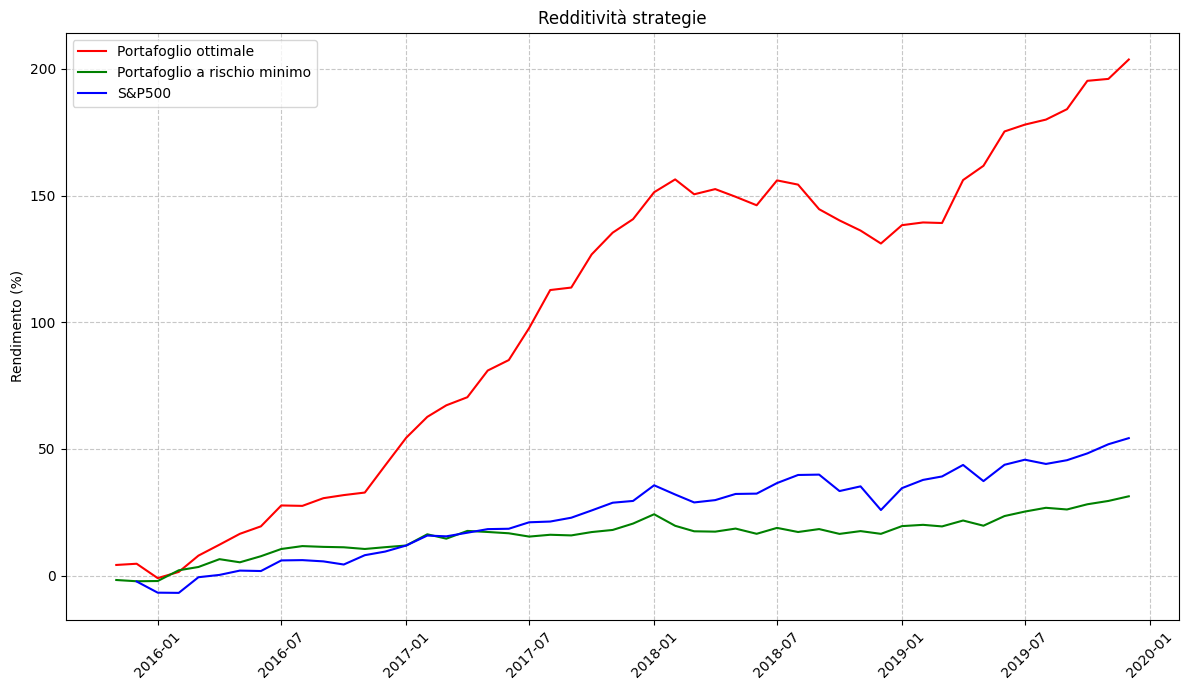

In [33]:
plt.figure(figsize=(12, 7))

plt.plot(cumulative_returns['Optimal'], 
         label='Portafoglio ottimale', 
         color='red')

plt.plot(cumulative_returns['Min Risk'], 
         label='Portafoglio a rischio minimo', 
         color='green')

plt.plot(sp500_cumulative_returns,
         label='S&P500',
         color='blue')

plt.title('Redditività strategie')
plt.ylabel('Rendimento (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()